In [1]:
import pandas as pd

In [2]:
from Descriptive import Descriptive

In [3]:
obj=Descriptive()

In [4]:
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS" #NSE stocks usually end with .NS
#dowload the stock data from NSE
stk_data=yf.download(stock_symbol, start="2024-05-01", end="2025-10-09")

[*********************100%***********************]  1 of 1 completed


In [5]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 358 entries, 2024-05-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   358 non-null    float64
 1   (High, RELIANCE.NS)    358 non-null    float64
 2   (Low, RELIANCE.NS)     358 non-null    float64
 3   (Open, RELIANCE.NS)    358 non-null    float64
 4   (Volume, RELIANCE.NS)  358 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.8 KB


In [6]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [7]:
stk_data

Price,Open,High,Low,Close
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2024-05-02,1454.460329,1459.721831,1446.679164,1449.075317
2024-05-03,1453.472210,1457.375095,1399.275803,1416.913086
2024-05-06,1418.395221,1422.841601,1401.103743,1402.610596
2024-05-07,1399.102859,1403.820987,1375.413559,1384.775635
2024-05-08,1380.848112,1415.875659,1380.848112,1401.647339
...,...,...,...,...
2025-10-01,1360.708629,1372.255218,1356.428371,1362.400757
2025-10-03,1356.926092,1365.287457,1350.655159,1357.125244


In [8]:
column="Close"

In [20]:
from sklearn.preprocessing import MinMaxScaler

y = stk_data[["Close"]]
X = stk_data[["Open", "High", "Low"]]

scaler_y = MinMaxScaler()
scaler_x = MinMaxScaler()

y = scaler_y.fit_transform(y)
X = scaler_x.fit_transform(X)

split = int(len(y) * 0.8)

train_y = y[:split]
test_y = y[split:]

train_x = X[:split]
test_x = X[split:]
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[["Close"]])

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [32]:
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    pred = model_fit.predict(start=len(train_y), end=len(train_y)+len(test_y)-1, exog=test_x)
    model_fit = model.fit()
    # make prediction
    actual = scaler_y.inverse_transform(test_y)
    predicted = scaler_y.inverse_transform(pred.reshape(-1,1))
    y_pred = model_fit.predict(start=len(train_y), end=len(y)-1, exog=test_x)
    #print(y_pred)
    from stockFunctions1 import rmsemape
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("RMSE :", rmse)

C:\Users\manju\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE : 6.924502878338268


C:\Users\manju\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE : 6.924502878338268


C:\Users\manju\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE : 6.924502878338268
RMSE : 6.924502878338268


C:\Users\manju\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [33]:
future_x = np.array([
    [1450,1462,1440],
    [1455,1470,1448],
    [1462,1475,1456],
    [1470,1485,1464],
    [1478,1490,1470]
])

future_x = scaler_x.transform(future_x)

forecast = model_fit.forecast(
    steps=5,
    exog=future_x
)

forecast = scaler_y.inverse_transform(forecast.reshape(-1,1))

print(forecast)

[[1449.10458147]
 [1459.9522595 ]
 [1465.08778547]
 [1474.47926558]
 [1478.22010807]]


In [34]:
len(y_pred)

72

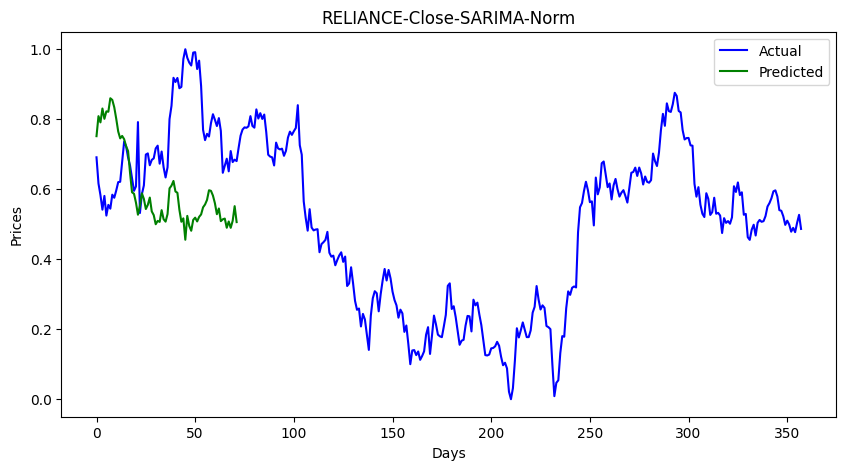

In [35]:
from stockFunctions1 import graph
graph(data1, y_pred,"Actual","Predicted","RELIANCE-Close-SARIMA-Norm","Days","Prices")

In [36]:
len(data1)

358

In [37]:
from stockFunctions1 import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [38]:
from stockFunctions1 import conversionSingle
pTestNormTable=conversionSingle(data1,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

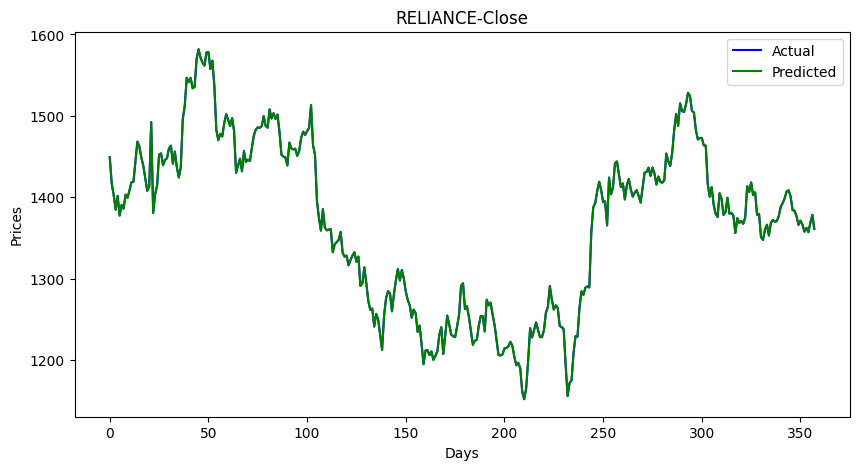

In [39]:
from stockFunctions1 import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","RELIANCE-Close","Days","Prices")

In [40]:
from stockFunctions1 import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 0.0
MAPE-Testset: 0.0


In [41]:
from stockFunctions1 import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [42]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [43]:
forecast_stock_price_test_oriF

,Closefore
0,1449.075317
1,1416.913086
2,1402.610596
3,1384.775635
4,1401.647339
...,...
353,1362.400757
354,1357.125244
355,1368.671875
356,1378.426758


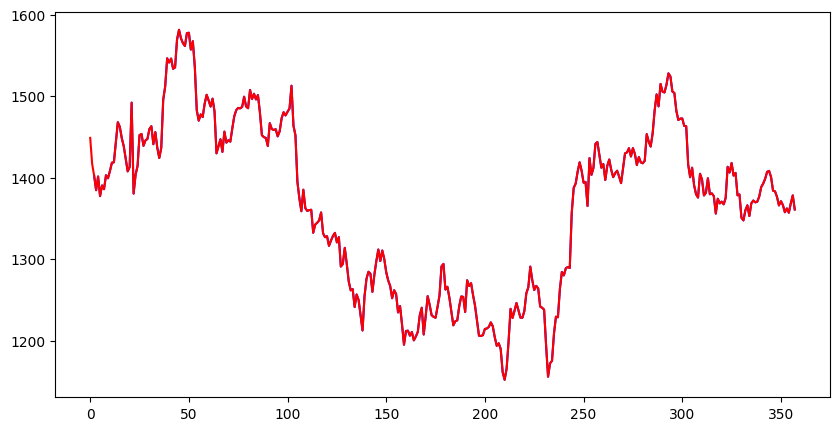

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[2:2225], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")
